In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install opencv-python numpy insightface matplotlib ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 30.8 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp311-cp311-linux_x86_64.whl size=1064782 sha256=931afc48bc4fed2a4744c77a233aa11db6f1f59

In [3]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.7 MB/s eta 0:00:00


In [4]:
# FACE DECTECTION WITH MATCHING

In [5]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import matplotlib.pyplot as plt
import math
from ultralytics import YOLO  # assuming YOLOv8

# Loading YOLO model
yolo_model = YOLO("/kaggle/input/local-data/Project  2.0/best_yolo_model.pt")  

# Initialize InsightFace
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(320, 320))


def extract_embedding(image_path, temp, printimage=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Error: Couldn't load '{image_path}'")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = yolo_model(img_rgb)
    detections = results[0].boxes

    if detections is None or len(detections) == 0:
        print(f"❌ No face detected in {image_path}")
        return None

    embeddings = []
    valid_face_count = 0  
    total_detections = len(detections)
    rows = min(5, total_detections)
    cols = math.ceil(total_detections / rows)

    for idx, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, img.shape[1]), min(y2, img.shape[0])

        face_crop = img[y1:y2, x1:x2]

        detected_faces = app.get(face_crop)

        if len(detected_faces) > 0:
            embedding = detected_faces[0].normed_embedding
            embeddings.append(embedding)
            temp.append(face_crop)

    return embeddings


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 85289.82KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)


In [6]:
import os
import pickle
import numpy as np

REFERENCE_PATH = r"/kaggle/input/local-data/Project  2.0/faces/faces"

def create_composite_embeddings():
    reference_embeddings = {}

    for person in os.listdir(REFERENCE_PATH):
        person_path = os.path.join(REFERENCE_PATH, person)
        if not os.path.isdir(person_path):
            continue
        
        embeddings = []
        for img_file in os.listdir(person_path):
            image_path = os.path.join(person_path, img_file)
            temp2 = []
            embedding = extract_embedding(image_path, temp2)

            if embedding is not None:
                embedding = np.array(embedding).squeeze()  # Ensures correct shape
                embeddings.append(embedding)

        if embeddings:
            try:
                composite_embedding = np.mean(np.vstack(embeddings), axis=0)
                reference_embeddings[person] = composite_embedding
                print(f"✅ Composite embedding generated for {person}")
            except ValueError as e:
                print(f"❌ Error merging embeddings for {person}: {e}")

    # Save embeddings to pkl file
    with open("reference_embeddings.pkl", "wb") as f:
        pickle.dump(reference_embeddings, f)

    print("All reference embeddings saved successfully.")

In [7]:
create_composite_embeddings()
# Here composite embeddings for each person in the dataset will be created
# Embeddings are stored in reference_embeddings.pkl


0: 640x640 1 face, 1247.4ms
Speed: 12.1ms preprocess, 1247.4ms inference, 18.7ms postprocess per image at shape (1, 3, 640, 640)


/usr/local/lib/python3.11/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4



0: 640x480 1 face, 866.4ms
Speed: 2.7ms preprocess, 866.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 1 face, 839.7ms
Speed: 2.7ms preprocess, 839.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 2 faces, 825.7ms
Speed: 2.7ms preprocess, 825.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
✅ Composite embedding generated for Roshan

0: 640x480 1 face, 809.9ms
Speed: 3.2ms preprocess, 809.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)

0: 640x512 1 face, 948.1ms
Speed: 3.0ms preprocess, 948.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 512)

0: 640x480 1 face, 866.1ms
Speed: 3.9ms preprocess, 866.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
✅ Composite embedding generated for Hari Krishna

0: 640x160 3 faces, 377.1ms
Speed: 2.7ms preprocess, 377.1ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 160)

0: 640x384 1 face, 750.

In [8]:
import pickle
import numpy as np

# Load reference embeddings
with open("reference_embeddings.pkl", "rb") as f:
    reference_embeddings = pickle.load(f)

# Convert reference embeddings (M×512) to a NumPy array of shape (M, 512)
persons = list(reference_embeddings.keys()) 
ref_matrix = np.array([reference_embeddings[person] for person in persons])  # Shape: (M, 512)

# Function to identify persons based on current embeddings
def identify_person(group_embeddings, threshold=0.5):
    group_embeddings = np.array(group_embeddings)  # Shape: (N, 512)

    # Invert current embeddings (N×512 → 512×N)
    group_matrix = group_embeddings.T  # Shape: (512, N)

    # Compute similarity using matrix multiplication (M×512) · (512×N) = (M×N)
    similarity_matrix = np.dot(ref_matrix, group_matrix)  # Shape: (M, N)

    # Normalize similarity scores 
    similarity_matrix = (similarity_matrix - similarity_matrix.min()) / (similarity_matrix.max() - similarity_matrix.min())

    match_results = []

    # Iterate through each row (M) — checking reference persons with group persons
    for i, similarities in enumerate(similarity_matrix):
        best_idx = np.argmax(similarities)  # Index of max similarity
        best_score = similarities[best_idx]  # Max similarity score

        if best_score > threshold:
            match_results.append((persons[i], best_idx, best_score))

    return match_results



In [9]:
temp2=[]
embedding_vectors2 = extract_embedding("/kaggle/input/local-data/Project  2.0/allimages/allimages/7all.jpg",temp2,True)


0: 480x640 46 faces, 862.1ms
Speed: 4.1ms preprocess, 862.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


In [10]:
matches = identify_person(embedding_vectors2, 0.7)

# Sort matches by confidence score in descending order
matches.sort(key=lambda x: x[2], reverse=True)

for idx, person, score in matches:
    print(f"Face {idx} matches {person} with confidence {score:.2f}")

Face Rohan Rudra matches 0 with confidence 1.00
Face Aditya Abhilash matches 10 with confidence 0.94
Face Animesh matches 26 with confidence 0.91
Face Sreekar matches 11 with confidence 0.90
Face Rohith matches 36 with confidence 0.89
Face Ajay matches 25 with confidence 0.86
Face Hari Krishna matches 43 with confidence 0.84
Face Deven matches 29 with confidence 0.76
Face Ayush Gupta matches 24 with confidence 0.76
Face Roshan matches 44 with confidence 0.73


In [11]:
# FACE DETECTION Code

In [12]:
from ultralytics import YOLO
import os

# Load your trained model (automatically picks best.pt from last run)
model = YOLO("/kaggle/input/local-data/Project  2.0/best_yolo_model.pt")

In [13]:
img_dir = '/kaggle/input/local-data/Project  2.0/allimages/allimages'

# Get all image paths (supports .jpg, .png, .jpeg, etc.)
image_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

results = model.predict(
    source=image_paths,  
    conf=0.25,  
    save=True,  
    save_txt=False,
    show=True 
)



WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 39 faces, 1232.8ms
1: 640x640 54 faces, 1232.8ms
2: 640x640 41 faces, 1232.8ms
3: 640x640 8 faces, 1232.8ms
4: 640x640 5 faces, 1232.8ms
5: 640x640 8 faces, 1232.8ms
6: 640x640 8 faces, 1232.8ms
7: 640x640 54 faces, 1232.8ms
Speed: 3.6ms preprocess, 1232.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


In [14]:
import os

input_folder = "/kaggle/input/local-data/Project  2.0/allimages/allimages"
output_folder = "/kaggle/working/annotated_results"
os.makedirs(output_folder, exist_ok=True)

#Looping through all images and its boxes/rectangles in the folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(input_folder, filename)
        image = cv2.imread(image_path)

        results = model(image_path)[0]

        # Draw bounding boxes and small text
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf)
            label = f"face {conf:.2f}"
            

            # Scaling the rectangle and the text to be smaller 
            font_scale = 0.4
            font_thickness = 1
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
            cv2.rectangle(image, (x1, y1 - h - 5), (x1 + w, y1), (255, 0, 0), -1)
            cv2.putText(image, label, (x1, y1 - 2), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

        # Save annotated image
        out_path = os.path.join(output_folder, filename)
        cv2.imwrite(out_path, image)

print(f"✅ All images processed. Check output in: {output_folder}")



image 1/1 /kaggle/input/local-data/Project  2.0/allimages/allimages/1all.jpg: 480x640 39 faces, 824.0ms
Speed: 3.5ms preprocess, 824.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/input/local-data/Project  2.0/allimages/allimages/6all.jpg: 480x640 54 faces, 853.5ms
Speed: 3.0ms preprocess, 853.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/input/local-data/Project  2.0/allimages/allimages/5all.jpg: 480x640 41 faces, 836.0ms
Speed: 3.6ms preprocess, 836.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/input/local-data/Project  2.0/allimages/allimages/2all.jpg: 288x640 8 faces, 549.2ms
Speed: 2.3ms preprocess, 549.2ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /kaggle/input/local-data/Project  2.0/allimages/allimages/4all.jpg: 480x640 5 faces, 825.7ms
Speed: 3.5ms preprocess, 825.7ms inference, 1.3ms postprocess per image at shape (1, 

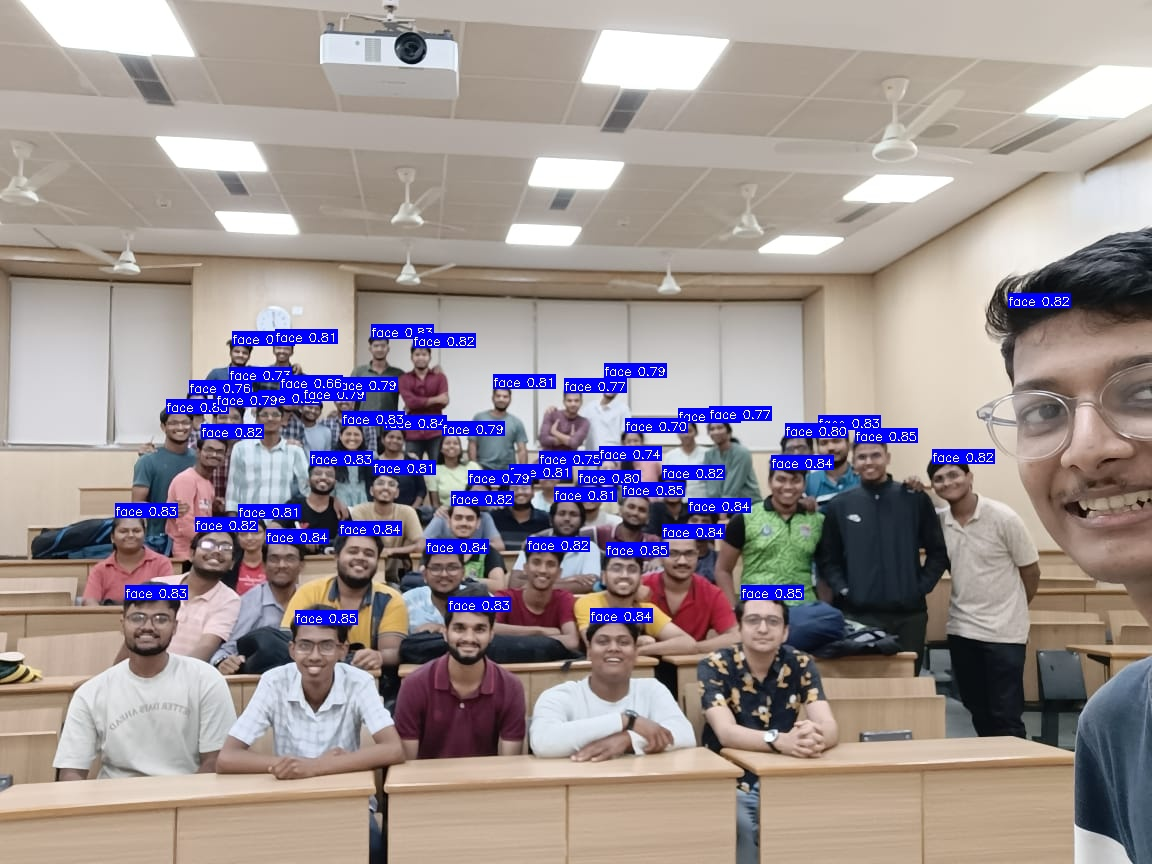

In [15]:
import IPython.display as display
from PIL import Image


img_path = "/kaggle/working/annotated_results/6all.jpg"  # adjust filename if different
display.display(Image.open(img_path))